# NOTEBOOK 2 : MODELE DE MARKOV
## Matrices de transition pour la dynamique du RA

## Theorie

### Chaine de Markov

Processus stochastique verifiant la propriete Markovienne :

$$P(X_{t+1}=j | X_t=i, X_{t-1},...) = P(X_{t+1}=j | X_t=i) = p_{ij}(t)$$

L'etat futur depend uniquement de l'etat present.

### Les 4 etats du RA

| Etat | Condition | Signification |
|------|-----------|---------------|
| 1 | ER = 0 | Pas de RA |
| 2 | 0 < ER <= 0.33 | RA faible |
| 3 | 0.33 < ER <= 0.67 | RA moyen |
| 4 | ER > 0.67 | RA fort |

### Matrice triangulaire superieure

Un RA ne peut qu'augmenter (irreversible) => matrice triangulaire superieure :

$$M(t) = \begin{pmatrix} p_{11} & p_{12} & p_{13} & p_{14} \\ 0 & p_{22} & p_{23} & p_{24} \\ 0 & 0 & p_{33} & p_{34} \\ 0 & 0 & 0 & 1 \end{pmatrix}$$

### Estimation

$$p_{ij}(t) = \frac{n_{ij}(t)}{n_i(t)}$$

### Projection

$$\pi(t+1) = \pi(t) \cdot M(t)$$

$$E[ER(t)] = \sum_{s=1}^{4} \pi_s(t) \cdot \bar{ER}_s$$

### Distribution stationnaire

$$\pi_{stat} \cdot M = \pi_{stat}$$

Vecteur propre gauche associe a la valeur propre 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from numpy.linalg import eig
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Bibliotheques chargees')

Bibliotheques chargees


## Etape 1 : Preparation donnees

In [2]:
df = pd.read_excel("Base_ER_FR.xlsx")
for c in ["Unnamed: 19","MREVAU","MREVNU"]:
    if c in df.columns: df.drop(columns=[c], inplace=True)
df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str)+"01", format="%Y%m%d", errors="coerce")
if "E_EAD" in df.columns:
    df["EAD"]=df["E_EAD"]; df.drop(columns=["E_EAD","E_ONB"],inplace=True,errors="ignore")
df = df[df.get("EAD",1)>0]; df["RA"]=df["RA"].fillna(0)
for c in ["CLASSACT","CSP","produit"]:
    if c in df.columns: df[c]=df[c].astype("category")
df["Tx"]=df.groupby("produit",observed=True)["Tx"].transform(lambda x:x.fillna(x.median()))
df["Tx"]=df["Tx"].fillna(df["Tx"].median())
df["CSP"]=df["CSP"].cat.add_categories("Inconnu").fillna("Inconnu")
df["AGE_CLI"]=df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"]=df["MREVTOT"].fillna(df["MREVTOT"].median())
df["AGE_PRET"]=df["B_MAT"]-df["B_RESMAT"]
df=df[(df["AGE_PRET"]>=0)&(df["AGE_PRET"]<=df["B_MAT"])]
df["Taux_m"]=df["Tx"]/1200
df["Encours"]=df["MTECH"]*((1-(1+df["Taux_m"])**(-df["B_RESMAT"]))/df["Taux_m"])
df.loc[df["B_RESMAT"]==0,"Encours"]=0
df["Capital_initial"]=df["MTECH"]*((1-(1+df["Taux_m"])**(-df["NB_ECH"]))/df["Taux_m"])
df["ER_obs"]=(df["RA"]/df["Encours"]).clip(0,1)
df["FLAG_ER"]=(df["RA"]>0).astype(int)
df=df[df["Encours"]>0]
print(f"Donnees : {len(df)} | ER moyen : {df['ER_obs'].mean():.4f} | FLAG_ER : {df['FLAG_ER'].mean():.2%}")

Donnees : 26516 | ER moyen : 0.7649 | FLAG_ER : 97.10%


## Etape 2 : Definition des etats

In [3]:
def assign_state(er):
    if er==0: return 1
    elif er<=0.33: return 2
    elif er<=0.67: return 3
    else: return 4

df["Etat"] = df["ER_obs"].apply(assign_state)
er_mean_st = df.groupby("Etat")["ER_obs"].mean().reindex(range(1,5), fill_value=0)
labels_et = ["E1 Pas RA","E2 Faible","E3 Moyen","E4 Fort"]

bins=[0,12,24,36,60,float("inf")]
lbls_age=["0-12m","13-24m","25-36m","37-60m",">60m"]
df["Tranche"] = pd.cut(df["AGE_PRET"], bins=bins, labels=lbls_age, right=True)

print("DISTRIBUTION DES ETATS"); print("="*50)
for e in range(1,5):
    n=(df["Etat"]==e).sum()
    print(f"  {labels_et[e-1]} : {n} ({n/len(df):.1%})")
print("\nER moyen par etat :")
for e in range(1,5):
    print(f"  Etat {e} : {er_mean_st[e]:.4f}")

DISTRIBUTION DES ETATS
  E1 Pas RA : 769 (2.9%)
  E2 Faible : 4858 (18.3%)
  E3 Moyen : 1820 (6.9%)
  E4 Fort : 19069 (71.9%)

ER moyen par etat :
  Etat 1 : 0.0000
  Etat 2 : 0.1116
  Etat 3 : 0.4899
  Etat 4 : 0.9885


### Visualisation distribution

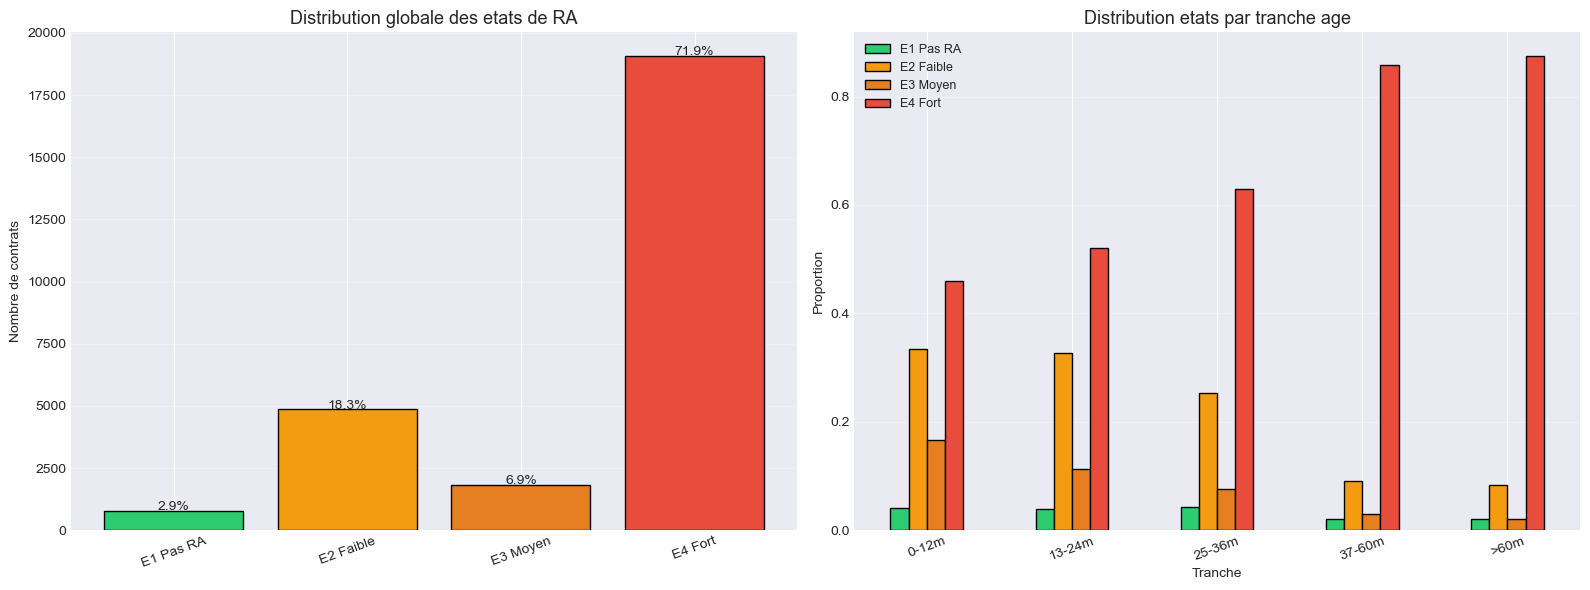

In [4]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
colors = ["#2ecc71","#f39c12","#e67e22","#e74c3c"]
counts = [(df["Etat"]==e).sum() for e in range(1,5)]
bars = axes[0].bar(labels_et, counts, color=colors, edgecolor="black")
for b,c in zip(bars,counts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+30, f"{c/len(df):.1%}", ha="center", fontsize=10)
axes[0].set_title("Distribution globale des etats de RA", fontsize=13)
axes[0].set_ylabel("Nombre de contrats"); axes[0].tick_params(axis="x",rotation=20)
axes[0].grid(True,alpha=0.3,axis="y")

dist = df.groupby("Tranche",observed=True)["Etat"].value_counts(normalize=True).unstack().fillna(0)
dist.plot(kind="bar",ax=axes[1],color=colors,edgecolor="black")
axes[1].set_title("Distribution etats par tranche age", fontsize=13)
axes[1].set_ylabel("Proportion"); axes[1].legend(labels_et,fontsize=9)
axes[1].tick_params(axis="x",rotation=20); axes[1].grid(True,alpha=0.3,axis="y")
plt.tight_layout(); plt.show()

## Etape 3 : Estimation des matrices de transition

In [5]:
def estimate_matrix(df_slice, n=4):
    dist = df_slice["Etat"].value_counts(normalize=True).reindex(range(1,n+1), fill_value=0)
    M = np.zeros((n,n))
    for i in range(n):
        pi = dist[i+1]
        if i==n-1: M[i,i]=1.0; continue
        M[i,i] = pi
        p_up = 1-pi
        sup = dist[range(i+2,n+1)]; s_sup=sup.sum()
        if s_sup>0:
            for j in range(i+1,n):
                M[i,j] = p_up*(dist[j+1]/s_sup)
        else: M[i,i]=1.0
        row_s = M[i,:].sum()
        if row_s>0: M[i,:]/=row_s
    return M, dist

matrices = {}
print("MATRICES DE TRANSITION PAR TRANCHE D'AGE"); print("="*70)
for tr in lbls_age:
    dft = df[df["Tranche"]==tr]
    if len(dft)>=30:
        M, dist = estimate_matrix(dft)
        matrices[tr] = M
        print(f"\nTranche {tr} ({len(dft)} contrats)")
        df_M = pd.DataFrame(M, index=[f"E{i+1}" for i in range(4)], columns=[f"E{i+1}" for i in range(4)])
        print(df_M.round(3))

MATRICES DE TRANSITION PAR TRANCHE D'AGE

Tranche 0-12m (4668 contrats)
      E1     E2     E3     E4
E1  0.04  0.334  0.167  0.459
E2  0.00  0.334  0.178  0.489
E3  0.00  0.000  0.167  0.833
E4  0.00  0.000  0.000  1.000

Tranche 13-24m (3561 contrats)
       E1     E2     E3     E4
E1  0.038  0.328  0.113  0.521
E2  0.000  0.328  0.120  0.552
E3  0.000  0.000  0.113  0.887
E4  0.000  0.000  0.000  1.000

Tranche 25-36m (3181 contrats)
       E1     E2     E3     E4
E1  0.042  0.253  0.075  0.630
E2  0.000  0.253  0.080  0.667
E3  0.000  0.000  0.075  0.925
E4  0.000  0.000  0.000  1.000

Tranche 37-60m (8676 contrats)
      E1     E2     E3     E4
E1  0.02  0.091  0.030  0.859
E2  0.00  0.091  0.031  0.878
E3  0.00  0.000  0.030  0.970
E4  0.00  0.000  0.000  1.000

Tranche >60m (6406 contrats)
       E1     E2     E3     E4
E1  0.021  0.083  0.021  0.875
E2  0.000  0.083  0.022  0.895
E3  0.000  0.000  0.021  0.979
E4  0.000  0.000  0.000  1.000


### Visualisation des matrices

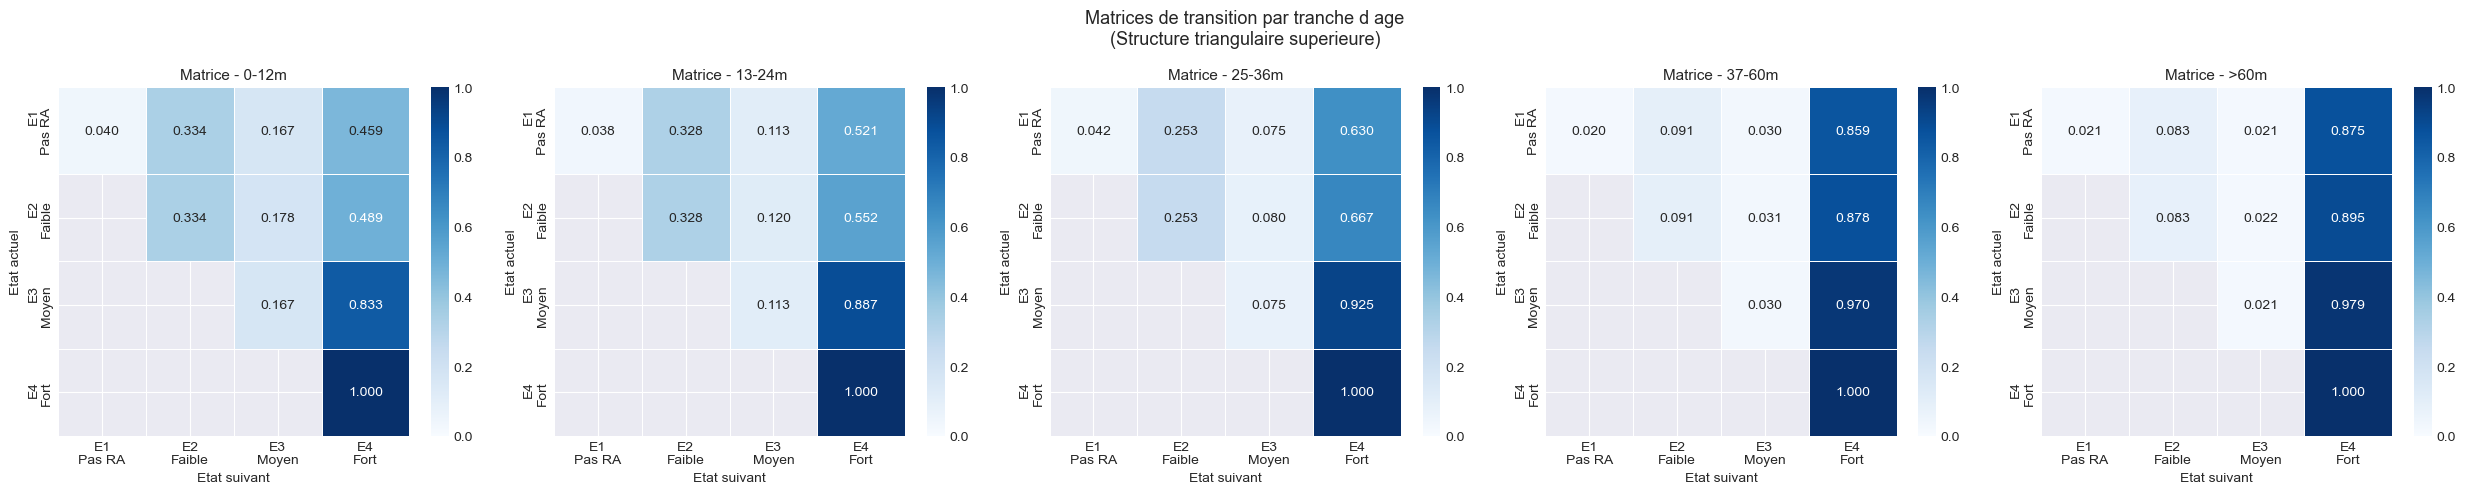

Interpretation : triangle inf. = 0 (pas de retour en arriere)


In [6]:
fig, axes = plt.subplots(1, len(matrices), figsize=(5*len(matrices),5))
if len(matrices)==1: axes=[axes]
sl = ["E1\nPas RA","E2\nFaible","E3\nMoyen","E4\nFort"]
for idx,(tr,M) in enumerate(matrices.items()):
    mask = np.tril(np.ones_like(M,dtype=bool),k=-1)
    sns.heatmap(M,annot=True,fmt=".3f",cmap="Blues",
                xticklabels=sl,yticklabels=sl,ax=axes[idx],
                vmin=0,vmax=1,linewidths=0.5,mask=mask)
    axes[idx].set_title(f"Matrice - {tr}",fontsize=11)
    axes[idx].set_xlabel("Etat suivant"); axes[idx].set_ylabel("Etat actuel")
plt.suptitle("Matrices de transition par tranche d age\n(Structure triangulaire superieure)", fontsize=13)
plt.tight_layout(); plt.show()
print("Interpretation : triangle inf. = 0 (pas de retour en arriere)")

## Etape 4 : Projection Markovienne sur 60 mois

In [7]:
pi_0 = np.array([(df[df["AGE_PRET"]<=12]["Etat"]==e).mean() for e in range(1,5)])
pi_0 = pi_0/pi_0.sum()
print("Distribution initiale :"); 
for i,p in enumerate(pi_0): print(f"  Etat {i+1} : {p:.4f} ({p:.1%})")

def get_M(age):
    if age<=12 and "0-12m" in matrices: return matrices["0-12m"]
    elif age<=24 and "13-24m" in matrices: return matrices["13-24m"]
    elif age<=36 and "25-36m" in matrices: return matrices["25-36m"]
    elif age<=60 and "37-60m" in matrices: return matrices["37-60m"]
    elif ">60m" in matrices: return matrices[">60m"]
    return np.eye(4)

n_mois=60
er_proj=[]; pi_hist=[pi_0.copy()]; pi_t=pi_0.copy()
for t in range(1,n_mois+1):
    pi_t = pi_t @ get_M(t)
    pi_t = pi_t/pi_t.sum()
    er_proj.append(sum(pi_t[s]*er_mean_st[s+1] for s in range(4)))
    pi_hist.append(pi_t.copy())

er_proj=np.array(er_proj); pi_hist=np.array(pi_hist)
print("\nProjection ER Markov :")
for t in [6,12,24,36,60]: print(f"  Age {t:2d}m : {er_proj[t-1]:.4f}")

Distribution initiale :
  Etat 1 : 0.0403 (4.0%)
  Etat 2 : 0.3333 (33.3%)
  Etat 3 : 0.1669 (16.7%)
  Etat 4 : 0.4595 (46.0%)

Projection ER Markov :
  Age  6m : 0.9877
  Age 12m : 0.9885
  Age 24m : 0.9885
  Age 36m : 0.9885
  Age 60m : 0.9885


### Visualisation projection

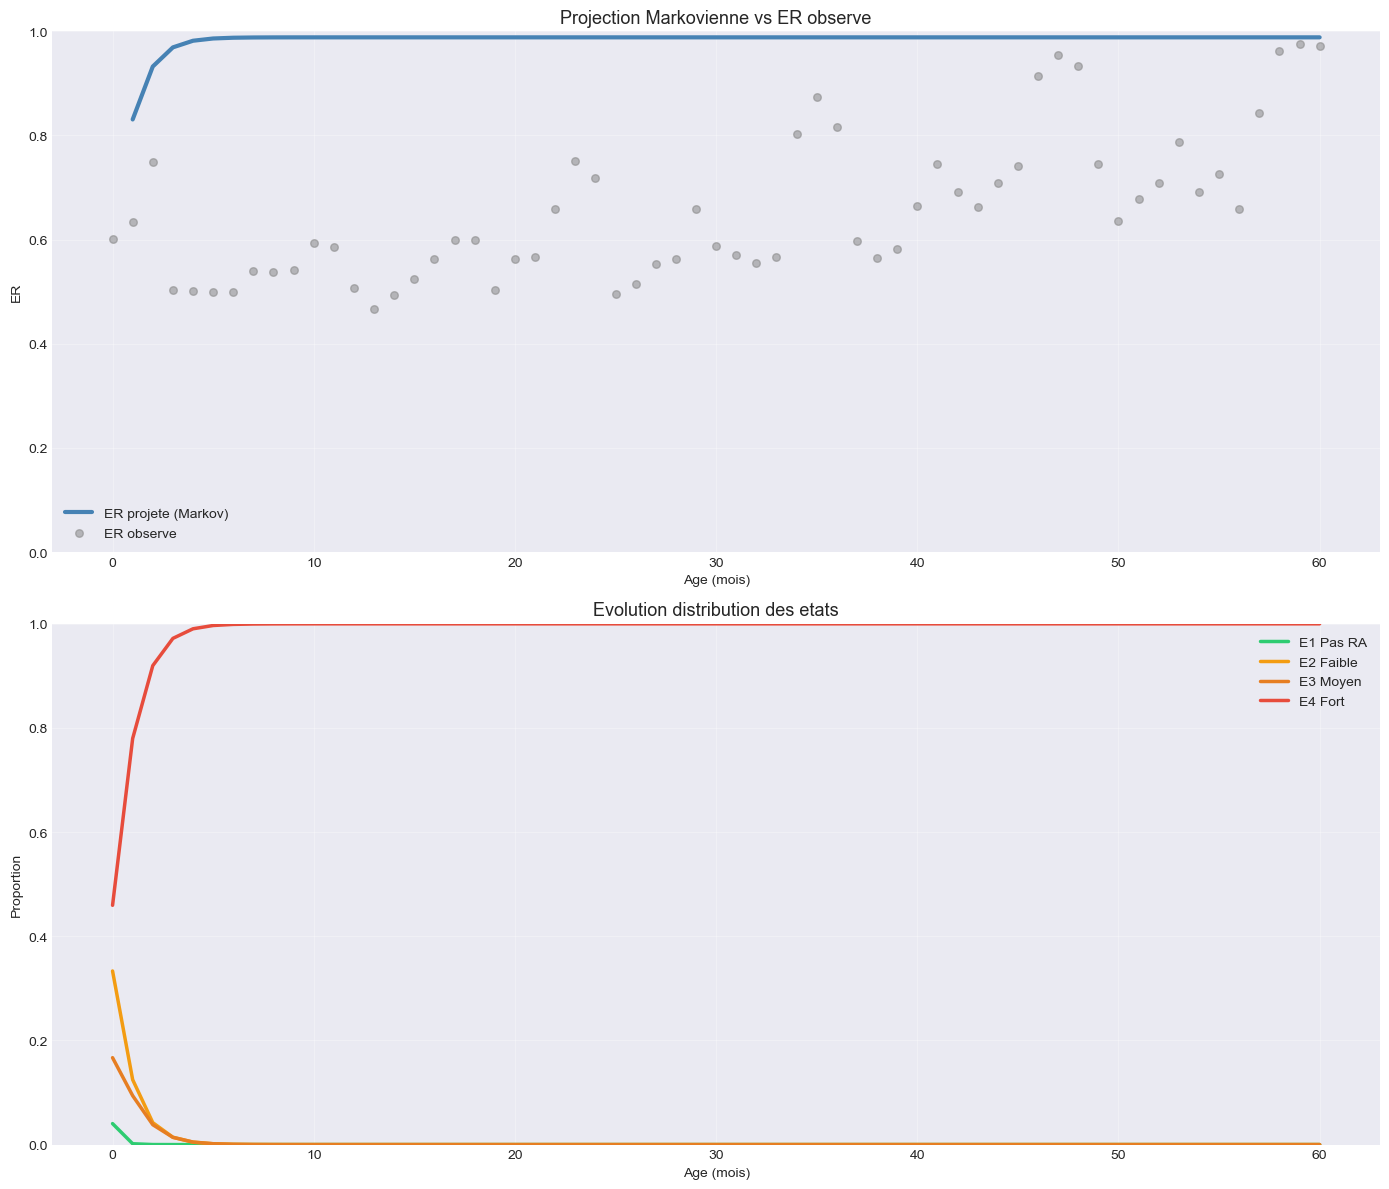

In [8]:
fig, axes = plt.subplots(2,1,figsize=(14,12))
colors_st=["#2ecc71","#f39c12","#e67e22","#e74c3c"]
er_obs_a = df.groupby("AGE_PRET")["ER_obs"].mean()
er_obs_a = er_obs_a[er_obs_a.index<=60]

axes[0].plot(range(1,n_mois+1),er_proj,linewidth=3,color="steelblue",label="ER projete (Markov)")
axes[0].scatter(er_obs_a.index,er_obs_a.values,alpha=0.5,s=30,color="gray",label="ER observe")
axes[0].set_xlabel("Age (mois)"); axes[0].set_ylabel("ER")
axes[0].set_title("Projection Markovienne vs ER observe",fontsize=13)
axes[0].legend(); axes[0].set_ylim(0,1); axes[0].grid(True,alpha=0.3)

for s in range(4):
    axes[1].plot(range(n_mois+1),pi_hist[:,s],linewidth=2.5,color=colors_st[s],label=labels_et[s])
axes[1].set_xlabel("Age (mois)"); axes[1].set_ylabel("Proportion")
axes[1].set_title("Evolution distribution des etats",fontsize=13)
axes[1].legend(); axes[1].set_ylim(0,1); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

## Etape 5 : Distribution stationnaire

DISTRIBUTION STATIONNAIRE (equilibre long terme)
  E1 Pas RA : 0.0000 (0.0%)
  E2 Faible : 0.0000 (0.0%)
  E3 Moyen : 0.0000 (0.0%)
  E4 Fort : 1.0000 (100.0%)

ER stationnaire : 0.9885


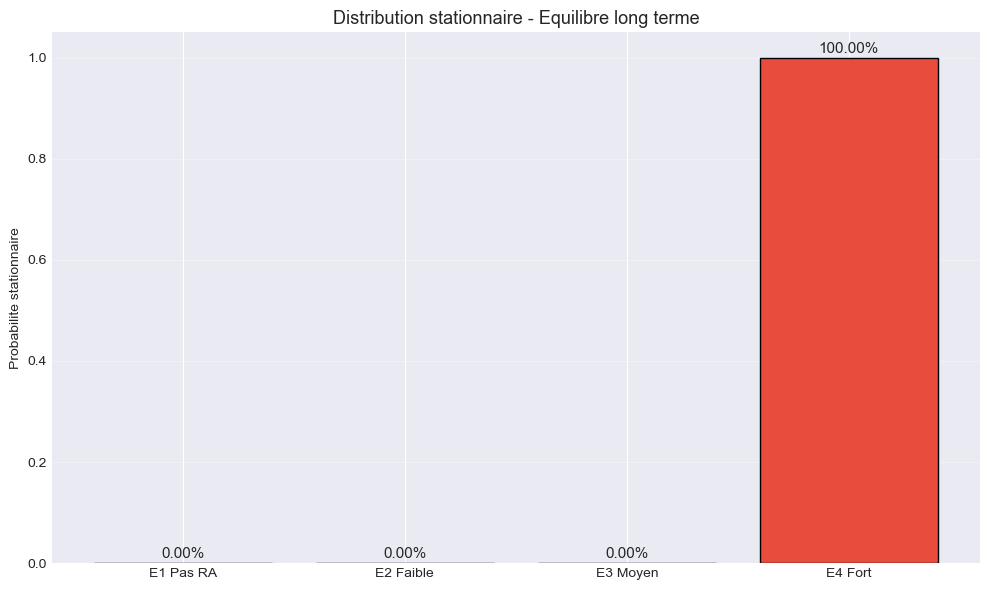

In [9]:
M_glob, _ = estimate_matrix(df)
eigenvalues, eigenvectors = eig(M_glob.T)
idx = np.argmin(np.abs(eigenvalues-1.0))
pi_stat = np.real(eigenvectors[:,idx])
pi_stat = pi_stat/pi_stat.sum()

print("DISTRIBUTION STATIONNAIRE (equilibre long terme)"); print("="*60)
for i,p in enumerate(pi_stat):
    print(f"  {labels_et[i]} : {p:.4f} ({p:.1%})")

er_stat = sum(pi_stat[s]*er_mean_st[s+1] for s in range(4))
print(f"\nER stationnaire : {er_stat:.4f}")

fig, ax = plt.subplots(figsize=(10,6))
colors_st=["#2ecc71","#f39c12","#e67e22","#e74c3c"]
bars = ax.bar(labels_et, pi_stat, color=colors_st, edgecolor="black")
for b,p in zip(bars,pi_stat):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{p:.2%}", ha="center", fontsize=11)
ax.set_title("Distribution stationnaire - Equilibre long terme", fontsize=13)
ax.set_ylabel("Probabilite stationnaire"); ax.grid(True,alpha=0.3,axis="y")
plt.tight_layout(); plt.show()

## Etape 6 : Prediction individuelle et evaluation

PERFORMANCE - MODELE MARKOVIEN
R2   : 0.2639
RMSE : 0.3201
MAE  : 0.1752


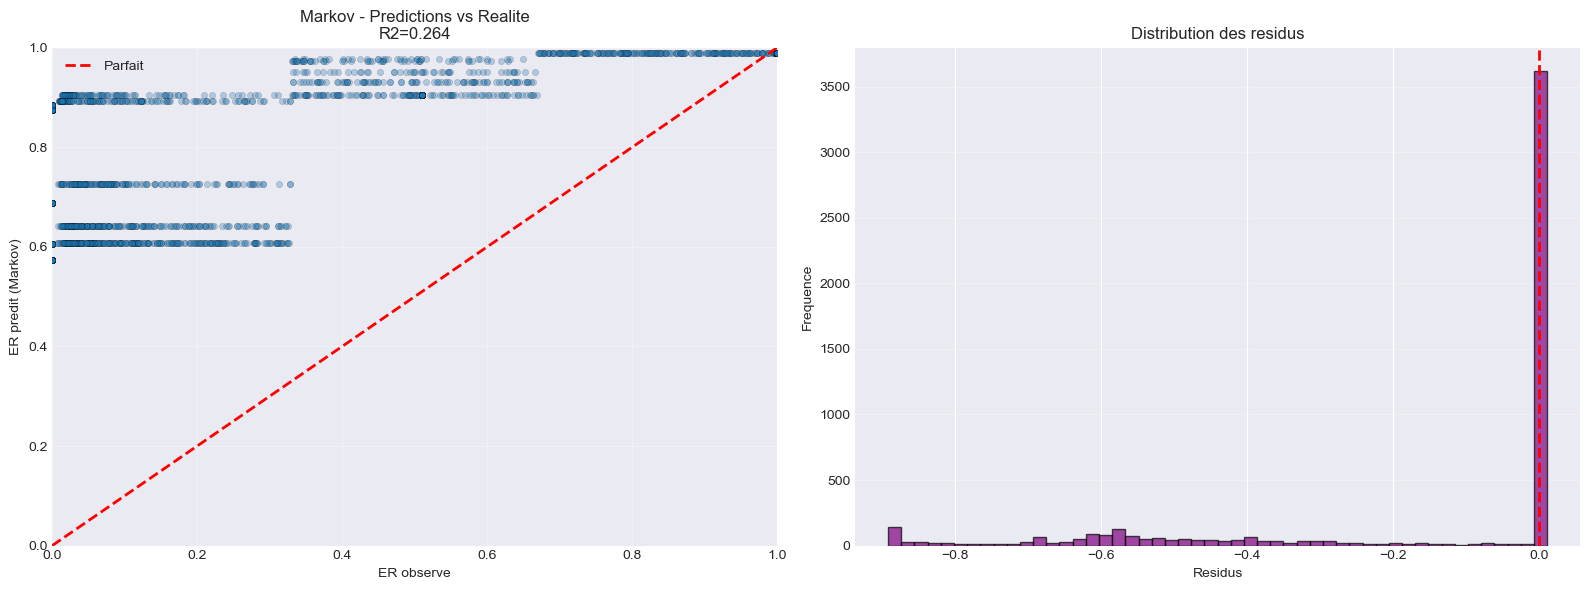


Matrices sauvegardees pour NB3


In [10]:
df["ER_Markov"] = df.apply(
    lambda r: sum(get_M(r["AGE_PRET"])[r["Etat"]-1,s]*er_mean_st[s+1] for s in range(4)), axis=1)

_, X_test, _, y_test = train_test_split(df[["AGE_PRET"]], df["ER_obs"], test_size=0.2, random_state=42)
y_pred = df.loc[X_test.index,"ER_Markov"].values

r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)

print("PERFORMANCE - MODELE MARKOVIEN"); print("="*60)
print(f"R2   : {r2:.4f}"); print(f"RMSE : {rmse:.4f}"); print(f"MAE  : {mae:.4f}")

fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].scatter(y_test,y_pred,alpha=0.3,s=20,edgecolors="black",linewidth=0.3)
axes[0].plot([0,1],[0,1],"r--",linewidth=2,label="Parfait")
axes[0].set_xlabel("ER observe"); axes[0].set_ylabel("ER predit (Markov)")
axes[0].set_title(f"Markov - Predictions vs Realite\nR2={r2:.3f}",fontsize=12)
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1); axes[0].legend(); axes[0].grid(True,alpha=0.3)

residuals = y_test.values - y_pred
axes[1].hist(residuals,bins=50,edgecolor="black",color="purple",alpha=0.7)
axes[1].axvline(0,color="red",linestyle="--",linewidth=2)
axes[1].set_xlabel("Residus"); axes[1].set_ylabel("Frequence")
axes[1].set_title("Distribution des residus",fontsize=12)
axes[1].grid(True,alpha=0.3,axis="y")
plt.tight_layout(); plt.show()

import pickle
with open("matrices_markov.pkl","wb") as f: pickle.dump(matrices,f)
with open("er_mean_st.pkl","wb") as f: pickle.dump(er_mean_st,f)
print("\nMatrices sauvegardees pour NB3")

## Synthese Modele Markovien

### Points forts
1. **Matrice triangulaire** : coherence economique (pas de retour arriere)
2. **Distribution stationnaire** : equilibre long terme du portefeuille
3. **Compatible cross-section** : une obs par contrat suffit
4. **Segmentation** : matrices differentes par tranche d'age

### Limites
1. **Propriete Markovienne** peut etre violee (dependance historique)
2. **Discretisation** : choix des seuils arbitraire
3. **R2 limite** : pas de caracteristiques individuelles

### Suite
NB3 combine Chain Ladder (NB1) + Markov (NB2) :
les facteurs CL calibrent les probabilites de transition.